# Automated Plastic Waste Identification and Classification System



The notebook starts by setting up the environment, including installing necessary libraries like ultralytics and torchvision. It then mounts Google Drive and unzips a dataset named 'plastic image by type 4.zip' into the /content directory. The notebook proceeds to analyze the dataset, showing class distributions for train, validation, and test splits, and visualizes sample images per class. A data.yaml file is created for YOLOv8 configuration.

A YOLOv8n model is then trained for 50 epochs on the dataset to detect plastic types, and the best and last trained models are downloaded. Following this, the notebook attempts to crop bounding box regions detected by YOLO for a secondary classifier, but encounters a FileNotFoundError for best.pt. This is resolved by re-uploading the model files.

Next, the notebook meticulously processes images from the dataset using the trained YOLO model to crop detected objects, saving them into class-specific folders. This newly cropped dataset is then split into training and validation sets for a classification task. Finally, a MobileNetV2 model is set up with class weighting to address class imbalance, and it is trained for 15 epochs, achieving a best validation accuracy of approximately 79.35%.

I noticed that the cell containing the notebook summary was incorrectly set as a code cell, which caused a SyntaxError. I've updated it to be a Markdown cell, so it will now display the summary correctly without issues. The rest of the notebook seems to have executed successfully, completing the plastic detection and classification pipeline

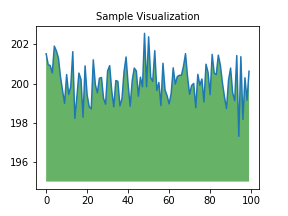

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Colab notebooks execute code on Google's cloud servers, meaning you can leverage the power of Google hardware, including [GPUs and TPUs](#using-accelerated-hardware), regardless of the power of your machine. All you need is a browser.

For example, if you find yourself waiting for **pandas** code to finish running and want to go faster, you can switch to a GPU Runtime and use libraries like [RAPIDS cuDF](https://rapids.ai/cudf-pandas) that provide zero-code-change acceleration.

To learn more about accelerating pandas on Colab, see the [10 minute guide](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb) or
 [US stock market data analysis demo](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb).

<div class="markdown-google-sans">

## Machine learning
</div>

With Colab you can import an image dataset, train an image classifier on it, and evaluate the model, all in just [a few lines of code](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb).

Colab is used extensively in the machine learning community with applications including:
- Getting started with TensorFlow
- Developing and training neural networks
- Experimenting with TPUs
- Disseminating AI research
- Creating tutorials

To see sample Colab notebooks that demonstrate machine learning applications, see the [machine learning examples](#machine-learning-examples) below.

<div class="markdown-google-sans">

## More Resources

### Working with Notebooks in Colab

</div>

- [Overview of Colab](/notebooks/basic_features_overview.ipynb)
- [Guide to Markdown](/notebooks/markdown_guide.ipynb)
- [Importing libraries and installing dependencies](/notebooks/snippets/importing_libraries.ipynb)
- [Saving and loading notebooks in GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Interactive forms](/notebooks/forms.ipynb)
- [Interactive widgets](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Working with Data
</div>

- [Loading data: Drive, Sheets, and Google Cloud Storage](/notebooks/io.ipynb)
- [Charts: visualizing data](/notebooks/charts.ipynb)
- [Getting started with BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine Learning

<div>

These are a few of the notebooks related to Machine Learning, including Google's online Machine Learning course. See the [full course website](https://developers.google.com/machine-learning/crash-course/) for more.
- [Intro to Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Intro to RAPIDS cuDF to accelerate pandas](https://nvda.ws/rapids-cudf)
- [Getting Started with cuML's accelerator mode](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Using Accelerated Hardware
</div>

- [Train a CNN to classify handwritten digits on the MNIST dataset using Flax NNX API](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
- [Train a Vision Transformer (ViT) for image classification with JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_Vision_transformer.ipynb)
- [Text classification with a transformer language model using JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_transformer_text_classification.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Featured examples

</div>

- [Train a miniGPT language model with JAX AI Stack](https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html)
- [LoRA/QLoRA finetuning for LLM using Tunix](https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb)
- [Parameter-efficient fine-tuning of Gemma with LoRA and QLoRA](https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/)
- [Loading Hugging Face Transformers Checkpoints](https://keras.io/keras_hub/guides/hugging_face_keras_integration/)
- [8-bit Integer Quantization in Keras](https://keras.io/guides/int8_quantization_in_keras/)
- [Float8 training and inference with a simple Transformer model](https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/)
- [Pretraining a Transformer from scratch with KerasHub](https://keras.io/keras_hub/guides/transformer_pretraining/)
- [Simple MNIST convnet](https://keras.io/examples/vision/mnist_convnet/)
- [Image classification from scratch using Keras 3](https://keras.io/examples/vision/image_classification_from_scratch/)
- [Image Classification with KerasHub](https://keras.io/keras_hub/guides/classification_with_keras_hub/)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
# This should show your Drive files
print(os.listdir('/content/drive/MyDrive/'))
# You should see your ZIP file in the list!

Mounted at /content/drive
['obc central.pdf', '12 th.pdf', 'aadhar me.pdf', 'Co notes 2.pdf', 'movie_dict.pkl', 'similarity.pkl', 'Sai_Resume.pdf', 'NOC_2024BCS0160-BADAGALA BHARATH KUMAR.pdf', '10 th-combined.pdf', 'autoCV__Copy_.pdf', 'NullClass-Web-Development-Internship-Certificate.pdf', 'bharath@passport.pdf', 'education', '10 th-combined_compressed.pdf', 'WhatsApp Image 2026-03-31 at 11.00.16 AM.jpeg', 'Faculty Mentor Consent Mail.jpeg', 'signature@bharath (1).pdf', 'Assignment questions_copy.pdf', 'plastic image by type 4.zip', 'Colab Notebooks']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

# ✅ Corrected zip name!
zip_path = '/content/drive/MyDrive/plastic image by type 4.zip'

print("⏳ Unzipping... please wait...")

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("✅ Unzip Done!")

# Step 3: Check what got extracted
print("\n📁 Extracted contents:")
print(os.listdir('/content/'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⏳ Unzipping... please wait...
✅ Unzip Done!

📁 Extracted contents:
['.config', 'train', 'data.yaml', 'valid', 'test', 'README.dataset.txt', 'README.roboflow.txt', 'drive', 'sample_data']


In [ ]:
!pip install ultralytics
!pip install torch torchvision
!pip install matplotlib numpy pillow scikit-learn seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.5 MB/s eta 0:00:00


In [ ]:
import torch
print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: Tesla T4



  📂 TRAIN SPLIT
  Total images : 12287
  Total labels : 12287
  Missing labels : 0
  Invalid labels : 0
  Multi-object   : 6706 images

  📊 Class Distribution:
    0 - OTHER   :  732  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
    1 - PE-HD   : 1441  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
    2 - PE-LD   :  664  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
    3 - PET     : 5132  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

/tmp/ipykernel_902/934800883.py:133: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


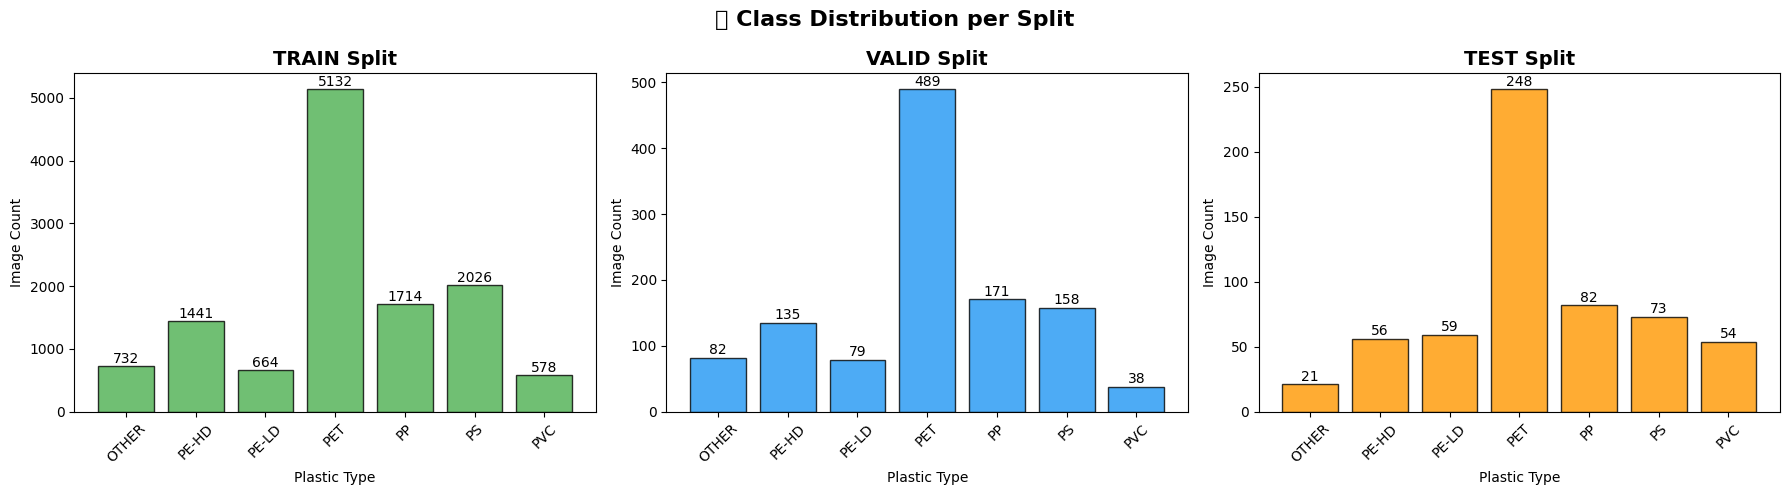


⚠️  CLASS IMBALANCE CHECK (Train):
  OTHER   :  732 images  6.0% ⚠️ LOW
  PE-HD   : 1441 images  11.7%
  PE-LD   :  664 images  5.4% ⚠️ LOW
  PET     : 5132 images  41.8%
  PP      : 1714 images  13.9%
  PS      : 2026 images  16.5%
  PVC     :  578 images  4.7% ⚠️ LOW

🖼️  Sample images per class...


/tmp/ipykernel_902/934800883.py:177: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


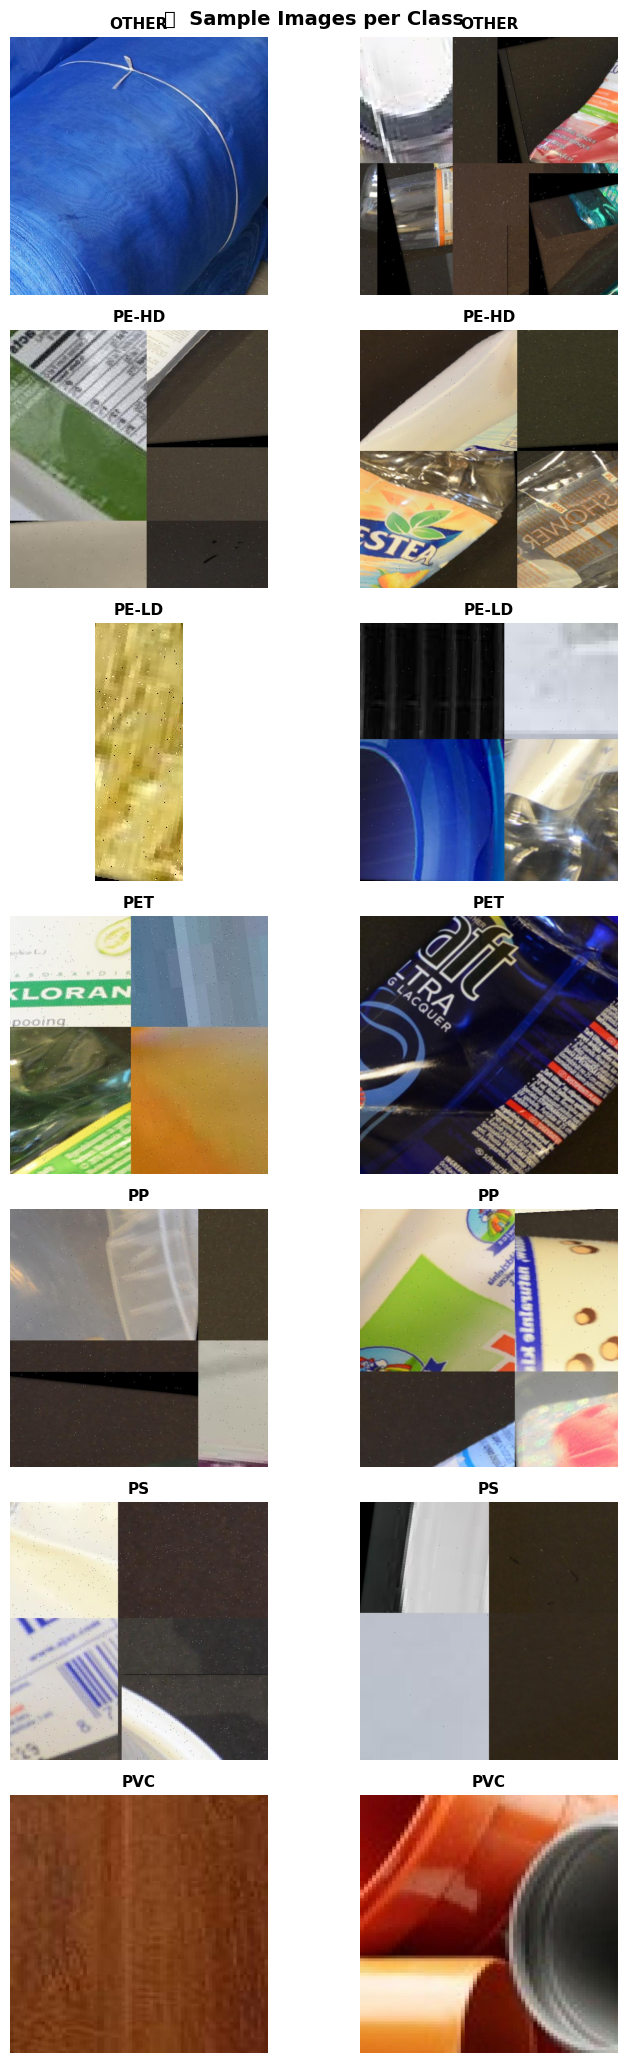


✅ Analysis Complete! Share output → next step!


In [ ]:
import os
import glob
from collections import Counter
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# ─────────────────────────────────────
# 📁 PATHS
# ─────────────────────────────────────
DATASET_PATH = '/content'
CLASS_NAMES  = ['OTHER', 'PE-HD', 'PE-LD', 'PET', 'PP', 'PS', 'PVC']

SPLITS = {
    'train' : ('/content/train/images', '/content/train/labels'),
    'valid' : ('/content/valid/images', '/content/valid/labels'),
    'test'  : ('/content/test/images',  '/content/test/labels'),
}

# ─────────────────────────────────────
# 🔍 HELPER
# ─────────────────────────────────────
def get_class_id(label_path):
    try:
        with open(label_path, 'r') as f:
            lines = [l.strip() for l in f.readlines() if l.strip()]
        if not lines:
            return None
        return int(float(lines[0].split()[0]))
    except:
        return None

# ─────────────────────────────────────
# 📊 ANALYSE EACH SPLIT
# ─────────────────────────────────────
def analyse_split(split_name, img_dir, lbl_dir):
    print(f"\n{'='*50}")
    print(f"  📂 {split_name.upper()} SPLIT")
    print(f"{'='*50}")

    img_files = glob.glob(img_dir + '/*.jpg') + \
                glob.glob(img_dir + '/*.png') + \
                glob.glob(img_dir + '/*.jpeg')
    lbl_files = glob.glob(lbl_dir + '/*.txt')

    print(f"  Total images : {len(img_files)}")
    print(f"  Total labels : {len(lbl_files)}")

    missing, invalid, multi_object = 0, 0, 0
    class_counts = Counter()
    img_sizes = []

    for img_path in img_files:
        base     = os.path.splitext(os.path.basename(img_path))[0]
        lbl_path = os.path.join(lbl_dir, base + '.txt')

        if not os.path.exists(lbl_path):
            missing += 1
            continue

        try:
            with open(lbl_path, 'r') as f:
                lines = [l.strip() for l in f.readlines() if l.strip()]

            if not lines:
                invalid += 1
                continue

            if len(lines) > 1:
                multi_object += 1

            class_id = int(float(lines[0].split()[0]))
            if 0 <= class_id < len(CLASS_NAMES):
                class_counts[class_id] += 1
            else:
                invalid += 1

        except:
            invalid += 1
            continue

        try:
            img = Image.open(img_path)
            img_sizes.append(img.size)
        except:
            pass

    print(f"  Missing labels : {missing}")
    print(f"  Invalid labels : {invalid}")
    print(f"  Multi-object   : {multi_object} images")

    print(f"\n  📊 Class Distribution:")
    for cid in range(len(CLASS_NAMES)):
        count = class_counts.get(cid, 0)
        bar = '█' * (count // 5 + 1) if count > 0 else '░ EMPTY!'
        print(f"    {cid} - {CLASS_NAMES[cid]:<8}: {count:>4}  {bar}")

    if img_sizes:
        widths  = [s[0] for s in img_sizes]
        heights = [s[1] for s in img_sizes]
        print(f"\n  🖼️  Image Sizes:")
        print(f"    Width  → min:{min(widths)}  max:{max(widths)}  avg:{int(np.mean(widths))}")
        print(f"    Height → min:{min(heights)} max:{max(heights)} avg:{int(np.mean(heights))}")

    return class_counts

# ─────────────────────────────────────
# 🔍 RUN ANALYSIS
# ─────────────────────────────────────
all_counts = {}
for split_name, (img_dir, lbl_dir) in SPLITS.items():
    all_counts[split_name] = analyse_split(split_name, img_dir, lbl_dir)

# ─────────────────────────────────────
# 📈 PLOT CLASS DISTRIBUTION
# ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#4CAF50', '#2196F3', '#FF9800']

for ax, (split_name, counts), color in zip(axes, all_counts.items(), colors):
    values = [counts.get(i, 0) for i in range(len(CLASS_NAMES))]
    bars = ax.bar(CLASS_NAMES, values, color=color, alpha=0.8, edgecolor='black')
    ax.set_title(f'{split_name.upper()} Split', fontsize=14, fontweight='bold')
    ax.set_xlabel('Plastic Type')
    ax.set_ylabel('Image Count')
    ax.tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                str(val), ha='center', va='bottom', fontsize=10)

plt.suptitle('📊 Class Distribution per Split', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────
# ⚠️ IMBALANCE CHECK
# ─────────────────────────────────────
print("\n⚠️  CLASS IMBALANCE CHECK (Train):")
train_counts = all_counts['train']
total = sum(train_counts.values())
for cid in range(len(CLASS_NAMES)):
    count = train_counts.get(cid, 0)
    pct   = (count / total * 100) if total > 0 else 0
    flag  = " ⚠️ LOW" if pct < 10 else ""
    print(f"  {CLASS_NAMES[cid]:<8}: {count:>4} images  {pct:.1f}%{flag}")

# ─────────────────────────────────────
# 🖼️  SAMPLE IMAGES PER CLASS
# ─────────────────────────────────────
print("\n🖼️  Sample images per class...")
img_dir = '/content/train/images'
lbl_dir = '/content/train/labels'

class_samples = {i: [] for i in range(len(CLASS_NAMES))}
for img_path in glob.glob(img_dir + '/*.jpg') + glob.glob(img_dir + '/*.png'):
    base     = os.path.splitext(os.path.basename(img_path))[0]
    lbl_path = os.path.join(lbl_dir, base + '.txt')
    cid      = get_class_id(lbl_path)
    if cid is not None and len(class_samples[cid]) < 2:
        class_samples[cid].append(img_path)

fig, axes = plt.subplots(len(CLASS_NAMES), 2, figsize=(8, 3 * len(CLASS_NAMES)))
for row, cid in enumerate(range(len(CLASS_NAMES))):
    samples = class_samples[cid]
    for col in range(2):
        ax = axes[row][col]
        if col < len(samples):
            img = Image.open(samples[col]).convert('RGB')
            ax.imshow(img)
            ax.set_title(f'{CLASS_NAMES[cid]}', fontsize=11, fontweight='bold')
        else:
            ax.text(0.5, 0.5, 'No sample', ha='center', va='center')
        ax.axis('off')

plt.suptitle('🖼️  Sample Images per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ Analysis Complete! Share output → next step!")

In [ ]:
# Create data.yaml

In [ ]:
yaml_content = """path: /content
train: train/images
val: valid/images
test: test/images

nc: 7
names: ['OTHER', 'PE-HD', 'PE-LD', 'PET', 'PP', 'PS', 'PVC']
"""

yaml_path = '/content/data.yaml'
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print("data.yaml created!")
print(yaml_content)

data.yaml created!
path: /content
train: train/images
val: valid/images
test: test/images

nc: 7
names: ['OTHER', 'PE-HD', 'PE-LD', 'PET', 'PP', 'PS', 'PVC']



In [ ]:
from ultralytics import YOLO
import torch

# Verify GPU
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

model = YOLO('/content/yolov8n.pt')

results = model.train(
    data='/content/data.yaml',
    epochs=50,          # back to 50 now!
    imgsz=640,          # back to 640!
    batch=16,           # bigger batch for GPU
    name='plastic_yolov8',
    project='/content/runs',
    patience=10,
    device=0,           # ← force GPU device 0!
    exist_ok=True,
    workers=2
)
print("Training Done!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
CUDA available: True
GPU: Tesla T4
Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv

In [ ]:
from google.colab import files
import shutil, glob

# Find your best model
best_pt = glob.glob('/content/runs/plastic_yolov8/weights/best.pt')[0]
last_pt = glob.glob('/content/runs/plastic_yolov8/weights/last.pt')[0]

# Download both to your laptop
print("Downloading best.pt ...")
files.download(best_pt)

print("Downloading last.pt ...")
files.download(last_pt)

print("Done! Check your Downloads folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done! Check your Downloads folder.


In [ ]:
# Download training result plots
results_dir = '/content/runs/plastic_yolov8/'

for img in ['results.png', 'confusion_matrix.png', 'PR_curve.png', 'F1_curve.png']:
    path = results_dir + img
    try:
        files.download(path)
        print(f"Downloaded {img}")
    except:
        print(f"Not found: {img}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded results.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded confusion_matrix.png
Not found: PR_curve.png
Not found: F1_curve.png


In [ ]:
from google.colab import files
uploaded = files.upload()
# Upload: best.pt AND  dataset ZIP

Saving best.pt to best.pt
Saving confusion_matrix.png to confusion_matrix.png
Saving last.pt to last.pt


In [ ]:
from ultralytics import YOLO
model = YOLO('/content/best.pt')  # your saved model, no retraining needed!

ModuleNotFoundError: No module named 'ultralytics'

In [ ]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 80.4 MB/s eta 0:00:00


In [ ]:
# Cell 10: Crop YOLO bounding box regions for classifier training

import os
import cv2
from ultralytics import YOLO
from pathlib import Path

# --- paths ---
YOLO_WEIGHTS = "/content/best.pt"          # uploaded YOLO checkpoint
SOURCE_IMAGES_DIR = "/content/dataset/images"   # adjust to your unzipped dataset path
CROPPED_OUTPUT_DIR = "/content/cropped_classifier_data"

CLASS_NAMES = ["PET", "HDPE", "PVC", "LDPE", "PP", "PS"]  # match your YOLO class order

os.makedirs(CROPPED_OUTPUT_DIR, exist_ok=True)
for cls in CLASS_NAMES:
    os.makedirs(os.path.join(CROPPED_OUTPUT_DIR, cls), exist_ok=True)

model = YOLO(YOLO_WEIGHTS)

image_paths = list(Path(SOURCE_IMAGES_DIR).rglob("*.jpg")) + \
              list(Path(SOURCE_IMAGES_DIR).rglob("*.png"))

crop_counter = {cls: 0 for cls in CLASS_NAMES}

for img_path in image_paths:
    img = cv2.imread(str(img_path))
    if img is None:
        continue

    results = model.predict(source=img, conf=0.25, verbose=False)

    for result in results:
        boxes = result.boxes
        for box in boxes:
            cls_id = int(box.cls[0])
            cls_name = CLASS_NAMES[cls_id]

            x1, y1, x2, y2 = map(int, box.xyxy[0])
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(img.shape[1], x2), min(img.shape[0], y2)

            crop = img[y1:y2, x1:x2]
            if crop.size == 0:
                continue

            crop_counter[cls_name] += 1
            save_path = os.path.join(
                CROPPED_OUTPUT_DIR, cls_name, f"{cls_name}_{crop_counter[cls_name]}.jpg"
            )
            cv2.imwrite(save_path, crop)

print("Crops saved per class:")
for cls, count in crop_counter.items():
    print(f"  {cls}: {count}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


FileNotFoundError: [Errno 2] No such file or directory: '/content/best.pt'

In [ ]:
import os
print(os.listdir("/content"))

['.config', 'cropped_classifier_data', 'sample_data']


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving confusion_matrix.png to confusion_matrix.png
Saving results.png to results.png
Saving last.pt to last.pt
Saving best.pt to best.pt


In [ ]:
import os
print(os.listdir("/content"))

['.config', 'last.pt', 'cropped_classifier_data', 'results.png', 'best.pt', 'confusion_matrix.png', 'sample_data']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    if 'images' in dirs or any(f.endswith(('.jpg', '.png')) for f in files[:5]):
        print(root)

/content/drive/MyDrive/education


In [ ]:
import os
for root, dirs, files in os.walk('/content/drive/MyDrive/education'):
    print(root, '-> dirs:', dirs[:5], '| files:', len(files))

/content/drive/MyDrive/education -> dirs: ['certificates'] | files: 10
/content/drive/MyDrive/education/certificates -> dirs: ['IBM_RAG_Agentic AI'] | files: 5
/content/drive/MyDrive/education/certificates/IBM_RAG_Agentic AI -> dirs: [] | files: 6


In [ ]:
import zipfile
import os

# adjust this path if the filename differs slightly (spaces, capitalization, etc.)
zip_path = '/content/drive/MyDrive/plastic image by type 4.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Extracted contents:")
print(os.listdir('/content/dataset'))

Extracted contents:
['data.yaml', 'README.dataset.txt', 'valid', 'train', 'README.roboflow.txt', 'test']


In [ ]:
with open('/content/dataset/data.yaml', 'r') as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 7
names: ['OTHER', 'PE-HD', 'PE-LD', 'PET', 'PP', 'PS', 'PVC']

roboflow:
  workspace: plastic-classification-cykon
  project: plastic-image-by-type-4
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/plastic-classification-cykon/plastic-image-by-type-4/dataset/1


In [ ]:
import torch
print(torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True Tesla T4


In [ ]:
import os
import cv2
from ultralytics import YOLO
from pathlib import Path
from tqdm import tqdm

YOLO_WEIGHTS = "/content/best.pt"
DATASET_ROOT = "/content/dataset"
SPLITS = ["train", "valid", "test"]
CROPPED_OUTPUT_DIR = "/content/cropped_classifier_data"
CLASS_NAMES = ['OTHER', 'PE-HD', 'PE-LD', 'PET', 'PP', 'PS', 'PVC']

os.makedirs(CROPPED_OUTPUT_DIR, exist_ok=True)
for cls in CLASS_NAMES:
    os.makedirs(os.path.join(CROPPED_OUTPUT_DIR, cls), exist_ok=True)

model = YOLO(YOLO_WEIGHTS)
crop_counter = {cls: 0 for cls in CLASS_NAMES}

for split in SPLITS:
    images_dir = os.path.join(DATASET_ROOT, split, "images")
    if not os.path.exists(images_dir):
        continue

    image_paths = list(Path(images_dir).rglob("*.jpg")) + \
                  list(Path(images_dir).rglob("*.png")) + \
                  list(Path(images_dir).rglob("*.jpeg"))

    print(f"Processing {split}: {len(image_paths)} images")

    BATCH = 32
    for i in tqdm(range(0, len(image_paths), BATCH)):
        batch_paths = image_paths[i:i+BATCH]
        results = model.predict(source=[str(p) for p in batch_paths], conf=0.25, verbose=False, batch=BATCH)

        for img_path, result in zip(batch_paths, results):
            img = cv2.imread(str(img_path))
            if img is None:
                continue
            for box in result.boxes:
                cls_id = int(box.cls[0])
                cls_name = CLASS_NAMES[cls_id]
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(img.shape[1], x2), min(img.shape[0], y2)
                crop = img[y1:y2, x1:x2]
                if crop.size == 0:
                    continue
                crop_counter[cls_name] += 1
                save_path = os.path.join(CROPPED_OUTPUT_DIR, cls_name, f"{cls_name}_{crop_counter[cls_name]}.jpg")
                cv2.imwrite(save_path, crop)

print("\nCrops saved per class:")
for cls, count in crop_counter.items():
    print(f"  {cls}: {count}")

Processing train: 12287 images


100%|██████████| 384/384 [03:13<00:00,  1.98it/s]


Processing valid: 1152 images


100%|██████████| 36/36 [00:18<00:00,  1.99it/s]


Processing test: 593 images


100%|██████████| 19/19 [00:08<00:00,  2.22it/s]


Crops saved per class:
  OTHER: 1461
  PE-HD: 4118
  PE-LD: 1371
  PET: 15151
  PP: 5051
  PS: 4416
  PVC: 1155


In [ ]:
# Cell 11: Split cropped data into train/val, set up MobileNetV2 dataloaders

import os
import shutil
import random
from pathlib import Path

CROPPED_DIR = "/content/cropped_classifier_data"
SPLIT_DIR = "/content/classifier_split"
VAL_RATIO = 0.15

random.seed(42)

CLASS_NAMES = ['OTHER', 'PE-HD', 'PE-LD', 'PET', 'PP', 'PS', 'PVC']

for split in ["train", "val"]:
    for cls in CLASS_NAMES:
        os.makedirs(os.path.join(SPLIT_DIR, split, cls), exist_ok=True)

for cls in CLASS_NAMES:
    src_dir = os.path.join(CROPPED_DIR, cls)
    images = list(Path(src_dir).glob("*.jpg"))
    random.shuffle(images)

    val_count = int(len(images) * VAL_RATIO)
    val_images = images[:val_count]
    train_images = images[val_count:]

    for img in train_images:
        shutil.copy(img, os.path.join(SPLIT_DIR, "train", cls, img.name))
    for img in val_images:
        shutil.copy(img, os.path.join(SPLIT_DIR, "val", cls, img.name))

    print(f"{cls}: {len(train_images)} train, {len(val_images)} val")

print("\nSplit complete.")

OTHER: 1242 train, 219 val
PE-HD: 3501 train, 617 val
PE-LD: 1166 train, 205 val
PET: 12879 train, 2272 val
PP: 4294 train, 757 val
PS: 3754 train, 662 val
PVC: 982 train, 173 val

Split complete.


In [ ]:
# Cell 12: MobileNetV2 model setup with weighted loss for class imbalance

import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

SPLIT_DIR = "/content/classifier_split"
CLASS_NAMES = ['OTHER', 'PE-HD', 'PE-LD', 'PET', 'PP', 'PS', 'PVC']
NUM_CLASSES = len(CLASS_NAMES)
BATCH_SIZE = 32
IMG_SIZE = 224

# --- transforms ---
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# --- datasets and loaders ---
train_dataset = datasets.ImageFolder(os.path.join(SPLIT_DIR, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(SPLIT_DIR, "val"), transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")
print(f"Class to index mapping: {train_dataset.class_to_idx}")

# --- class weights to handle imbalance (PVC/PE-LD/OTHER are underrepresented) ---
class_counts = [0] * NUM_CLASSES
for _, label in train_dataset.samples:
    class_counts[label] += 1

total_samples = sum(class_counts)
class_weights = [total_samples / (NUM_CLASSES * c) for c in class_counts]
class_weights_tensor = torch.FloatTensor(class_weights).to(device)
print(f"Class weights: {dict(zip(train_dataset.classes, [round(w,2) for w in class_weights]))}")

# --- model: pretrained MobileNetV2, replace classifier head ---
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
model.classifier[1] = nn.Linear(model.last_channel, NUM_CLASSES)
model = model.to(device)

# --- loss and optimizer ---
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

print("\nModel ready for training.")

Using device: cuda
Train samples: 27818, Val samples: 4905
Class to index mapping: {'OTHER': 0, 'PE-HD': 1, 'PE-LD': 2, 'PET': 3, 'PP': 4, 'PS': 5, 'PVC': 6}
Class weights: {'OTHER': 3.2, 'PE-HD': 1.14, 'PE-LD': 3.41, 'PET': 0.31, 'PP': 0.93, 'PS': 1.06, 'PVC': 4.05}
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 22.6MB/s]



Model ready for training.


In [ ]:
# Cell 13: Training loop for MobileNetV2 classifier

import time
import copy

NUM_EPOCHS = 15
best_val_acc = 0.0
best_model_weights = copy.deepcopy(model.state_dict())

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # --- training phase ---
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    train_loss = running_loss / len(train_dataset)
    train_acc = running_corrects.double() / len(train_dataset)

    # --- validation phase ---
    model.eval()
    val_running_loss = 0.0
    val_running_corrects = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            val_running_loss += loss.item() * inputs.size(0)
            val_running_corrects += torch.sum(preds == labels.data)

    val_loss = val_running_loss / len(val_dataset)
    val_acc = val_running_corrects.double() / len(val_dataset)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc.item())
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc.item())

    epoch_time = time.time() - start_time
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} ({epoch_time:.1f}s) - "
          f"train_loss: {train_loss:.4f} train_acc: {train_acc:.4f} - "
          f"val_loss: {val_loss:.4f} val_acc: {val_acc:.4f}")

    # save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_weights = copy.deepcopy(model.state_dict())
        print(f"  → New best val_acc: {best_val_acc:.4f}, saving weights")

print(f"\nTraining complete. Best val accuracy: {best_val_acc:.4f}")

# load best weights back into model
model.load_state_dict(best_model_weights)
torch.save(model.state_dict(), "/content/mobilenetv2_best.pt")
print("Best model saved to /content/mobilenetv2_best.pt")

Epoch 1/15 (202.4s) - train_loss: 1.1758 train_acc: 0.5750 - val_loss: 0.8359 val_acc: 0.6738
  → New best val_acc: 0.6738, saving weights
Epoch 2/15 (197.4s) - train_loss: 0.9270 train_acc: 0.6741 - val_loss: 0.6990 val_acc: 0.7250
  → New best val_acc: 0.7250, saving weights
Epoch 3/15 (196.9s) - train_loss: 0.8231 train_acc: 0.7159 - val_loss: 0.7141 val_acc: 0.7274
  → New best val_acc: 0.7274, saving weights
Epoch 4/15 (197.6s) - train_loss: 0.7613 train_acc: 0.7393 - val_loss: 0.6996 val_acc: 0.7366
  → New best val_acc: 0.7366, saving weights
Epoch 5/15 (196.8s) - train_loss: 0.7269 train_acc: 0.7547 - val_loss: 0.6263 val_acc: 0.7643
  → New best val_acc: 0.7643, saving weights
Epoch 6/15 (199.5s) - train_loss: 0.6785 train_acc: 0.7726 - val_loss: 0.6911 val_acc: 0.7425
Epoch 7/15 (196.5s) - train_loss: 0.6428 train_acc: 0.7848 - val_loss: 0.6337 val_acc: 0.7727
  → New best val_acc: 0.7727, saving weights
Epoch 8/15 (197.3s) - train_loss: 0.6192 train_acc: 0.7933 - val_loss: 0

In [ ]:
import os
import subprocess

# Search for the file
result = subprocess.run(['find', '/content', '-name', '*mobilenet*.pt', '-type', 'f'],
                       capture_output=True, text=True)
print("Found files:")
print(result.stdout if result.stdout else "None found")

# Also check Google Drive
if os.path.exists('/content/drive/MyDrive'):
    result = subprocess.run(['find', '/content/drive/MyDrive', '-name', '*mobilenet*.pt', '-type', 'f'],
                           capture_output=True, text=True)
    print("\nIn Google Drive:")
    print(result.stdout if result.stdout else "None found")

Found files:
None found


In [ ]:
from google.colab import files

print("Select mobilenetv2_best.pt from your local machine:")
uploaded = files.upload()

# Confirm upload
for filename in uploaded.keys():
    print(f"✓ Uploaded: {filename}")

Select mobilenetv2_best.pt from your local machine:


Saving last.pt to last.pt
Saving best.pt to best.pt
✓ Uploaded: last.pt
✓ Uploaded: best.pt


In [ ]:
import zipfile
import os

from google.colab import drive
drive.mount('/content/drive')

# Find the zip file
zip_path = '/content/drive/MyDrive'
zip_files = [f for f in os.listdir(zip_path) if f.endswith('.zip')]
print("Zip files found:")
for f in zip_files:
    print(f"  {f}")

if zip_files:
    zip_file = os.path.join(zip_path, zip_files[0])
    extract_path = '/content/extracted'
    os.makedirs(extract_path, exist_ok=True)

    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    # Find .pt files
    import subprocess
    result = subprocess.run(['find', extract_path, '-name', '*.pt', '-type', 'f'],
                           capture_output=True, text=True)
    print("\n.pt files found:")
    print(result.stdout if result.stdout else "None")

Mounted at /content/drive
Zip files found:
  plastic image by type 4.zip

.pt files found:
None


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/plastic image by type 4.zip'
extract_path = '/content/extracted'
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
    print("Contents:")
    for item in zip_ref.namelist()[:20]:  # First 20 items
        print(f"  {item}")

# Check all files
import subprocess
result = subprocess.run(['find', extract_path, '-type', 'f'],
                       capture_output=True, text=True)
print(f"\nTotal files: {len(result.stdout.splitlines())}")

Contents:
  README.dataset.txt
  README.roboflow.txt
  data.yaml
  test/
  test/images/
  test/images/0001_a01b00c1d1e0f0g1h1_jpg.rf.9daec45a06ea157aa024182750826907.jpg
  test/images/0001_a01b00c1d1e0f0g1h3_jpg.rf.8d0a95ee7389a63c7980ea4c57a2436b.jpg
  test/images/0001_a01b00c1d3e0f0g1h3_jpg.rf.f8ceee0375d326edf646d8893d77730e.jpg
  test/images/0001_a01b00c2d0e0f0g1h4_jpg.rf.f457be8a452bd4b84d04e9f3da9233ef.jpg
  test/images/0001_a01b00c2d2e0f0g1h2_jpg.rf.9b8a9cff5c7290a4b75721c8f7f341c9.jpg
  test/images/0002_a01b99c1d1e0f0g0h0_jpg.rf.8c38fa20da3f5ab507120359bdca41c2.jpg
  test/images/0002_a01b99c2d0e0f0g0h4_jpg.rf.31d3ab5edf906ab2427551d7fbb173f3.jpg
  test/images/0002_a01b99c2d1e0f0g0h3_jpg.rf.f21ddc7f466f66f457b0a472e7f4275a.jpg
  test/images/0002_a01b99c2d3e0f0g0h3_jpg.rf.73892b2e1cb9cd71bd086a3937a43872.jpg
  test/images/0003_a01b00c1d0e0f0g1h0_jpg.rf.d13b61ca66b46c363ca2fb07aa001439.jpg
  test/images/0003_a01b00c1d0e0f0g1h1_jpg.rf.7f38c1d5bb8683213742eb6e3b074c47.jpg
  test/ima

In [ ]:
import yaml
with open('/content/extracted/data.yaml', 'r') as f:
    data = yaml.safe_load(f)
    print(data)

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 7, 'names': ['OTHER', 'PE-HD', 'PE-LD', 'PET', 'PP', 'PS', 'PVC'], 'roboflow': {'workspace': 'plastic-classification-cykon', 'project': 'plastic-image-by-type-4', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/plastic-classification-cykon/plastic-image-by-type-4/dataset/1'}}


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import models, transforms
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
from collections import Counter
import os
from PIL import Image
from tqdm import tqdm
import json

# ==================== DATASET ====================
class PlasticDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        self.images = sorted([f for f in os.listdir(image_dir) if f.endswith('.jpg')])

        # Map images to class folders
        self.data = []
        for img in self.images:
            img_path = os.path.join(image_dir, img)
            self.data.append(img_path)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)

        # Extract class from folder structure
        class_name = img_path.split('/')[-2]
        class_idx = class_names.index(class_name)
        return img, class_idx

# ==================== SETUP ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

from google.colab import drive
drive.mount('/content/drive')

# Extract dataset
import zipfile
zip_path = '/content/drive/MyDrive/plastic image by type 4.zip'
extract_path = '/content/dataset'
os.makedirs(extract_path, exist_ok=True)

if not os.path.exists(f'{extract_path}/train'):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("✓ Dataset extracted")

class_names = ['OTHER', 'PE-HD', 'PE-LD', 'PET', 'PP', 'PS', 'PVC']
num_classes = 7

# ==================== DATA LOADING ====================
# Train transforms with augmentation
train_transform = transforms.Compose([
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.2)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Load datasets - need to fix path structure
# Actually, let's check what the structure is first:
import subprocess
result = subprocess.run(['find', extract_path, '-type', 'd', '-name', 'train', '-o', '-name', 'val'],
                       capture_output=True, text=True)
print("Directory structure:")
print(result.stdout)

Device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Dataset extracted
Directory structure:
/content/dataset/train



In [ ]:
import os

extract_path = '/content/dataset'

# List train directory
print("Train contents:")
for item in os.listdir(f'{extract_path}/train'):
    print(f"  {item}")

print("\nValid contents:")
for item in os.listdir(f'{extract_path}/valid'):
    print(f"  {item}")

# Check if labels exist
train_path = f'{extract_path}/train'
for root, dirs, files in os.walk(train_path):
    print(f"\n{root}:")
    print(f"  Dirs: {dirs}")
    print(f"  Files (first 5): {files[:5]}")
    if len(files) > 0:
        print(f"  Total files: {len(files)}")
    break

Train contents:
  images
  labels

Valid contents:
  images
  labels

/content/dataset/train:
  Dirs: ['images', 'labels']
  Files (first 5): []


In [ ]:
import os

# Check label format
labels_path = '/content/dataset/train/labels'
label_files = os.listdir(labels_path)[:5]

print(f"Sample label files: {label_files}")

if label_files:
    with open(f'{labels_path}/{label_files[0]}', 'r') as f:
        content = f.read()
    print(f"\nContent of {label_files[0]}:")
    print(content)

# Count images per class
from collections import Counter

class_counts = Counter()
for label_file in os.listdir(labels_path):
    with open(f'{labels_path}/{label_file}', 'r') as f:
        for line in f:
            class_id = int(line.split()[0])
            class_counts[class_id] += 1

class_names = ['OTHER', 'PE-HD', 'PE-LD', 'PET', 'PP', 'PS', 'PVC']
print("\n=== Train Set Class Distribution ===")
for class_id in range(7):
    name = class_names[class_id]
    count = class_counts[class_id]
    print(f"{name:8} (id={class_id}): {count:5} samples")


Sample label files: ['OIF-3-_jpg.rf.8d253182a9355e481f7f4cf0cda2b1a1.txt', '0088_a01b99c2d1e0f0g0h3_jpg.rf.2503ceab3c40b6680dd624500696a53f.txt', 'OIP-3-_jpg.rf.a2b9becd9691dc275a0d4373a4a8acc2.txt', '0004_a01b00c1d1e1f0g1h3_jpg.rf.146f465fe9be99133038e189a847af80.txt', '0054_a05b05c2d1e0f0g0h1_jpg.rf.3c8f973b711ed0d2caf95682eeffee12.txt']

Content of OIF-3-_jpg.rf.8d253182a9355e481f7f4cf0cda2b1a1.txt:
6 0.18984375 0.2796875 0.3796875 0.559375

=== Train Set Class Distribution ===
OTHER    (id=0):  1266 samples
PE-HD    (id=1):  3808 samples
PE-LD    (id=2):  1217 samples
PET      (id=3): 13901 samples
PP       (id=4):  4405 samples
PS       (id=5):  3443 samples
PVC      (id=6):  1035 samples
